In [1]:
import pickle
from pathlib import Path

import numpy as np

import galaxy_zoo_sph as g  # the module we've been building; keep it next to this notebook

OUTDIR = Path("out")
OUTDIR.mkdir(exist_ok=True)

PARTICLE_CACHE = OUTDIR / "zoo_cache.pkl"     # simulated particles (x, y, [z] per galaxy)
FRAME_CACHE = OUTDIR / "zoo_frames.pkl"       # rendered face-on/edge-on slice arrays

In [2]:
# Runs the orbit integrations / Plummer sampling / merger encounters for all
# 10 galaxies (a few minutes) and caches the particles to disk. Re-running
# this cell reuses the cache instead of re-simulating, unless you delete
# PARTICLE_CACHE or pass only=[...] for galaxies not yet in it.
try:
    with open(PARTICLE_CACHE, "rb") as f:
        results = pickle.load(f)
    print(f"loaded cached particles for {len(results)} galaxies from {PARTICLE_CACHE}")
except (FileNotFoundError, EOFError):
    results = g.generate_all()  # n_disk=60000 by default
    with open(PARTICLE_CACHE, "wb") as f:
        pickle.dump(results, f)
    print(f"simulated and cached {len(results)} galaxies to {PARTICLE_CACHE}")

sorted(results)

simulated and cached 10 galaxies to out/zoo_cache.pkl


['10_dwarf_irregular',
 '1_grand_design',
 '2_tightly_wound',
 '3_flocculent',
 '4_barred_spiral',
 '5_lenticular',
 '6_elliptical_E0',
 '7_elliptical_E5',
 '8_interacting_pair',
 '9_merger_remnant']

In [3]:
# For each galaxy, builds the SPH, uniform-grid and pseudo-AMR yt datasets
# from the cached particles and extracts face-on / edge-on density slices.
# This is the part that actually calls yt, and is what --individual/--grids
# in the script's CLI controls; here we just keep the raw arrays. Also a
# few minutes; incrementally cached to FRAME_CACHE so a crash doesn't lose
# progress and re-running this cell is instant once done.
try:
    with open(FRAME_CACHE, "rb") as f:
        frames = pickle.load(f)
except (FileNotFoundError, EOFError):
    frames = {}

for name in g.ORDER:
    if name in frames:
        continue
    frames[name] = g.render_galaxy(name, results[name], outdir=str(OUTDIR))
    print(name, "AMR:", frames[name]["amr_info"])
    with open(FRAME_CACHE, "wb") as f:
        pickle.dump(frames, f)

print(f"rendered {len(frames)} galaxies")

1_grand_design AMR: {'n_grids': 3302, 'grids_per_level': [1, 880, 134, 469, 1452, 366], 'finest_cell_pc': 39.1}
2_tightly_wound AMR: {'n_grids': 2062, 'grids_per_level': [1, 880, 74, 192, 549, 366], 'finest_cell_pc': 39.1}
3_flocculent AMR: {'n_grids': 3354, 'grids_per_level': [1, 880, 220, 664, 1223, 366], 'finest_cell_pc': 39.1}
4_barred_spiral AMR: {'n_grids': 2719, 'grids_per_level': [1, 880, 156, 474, 842, 366], 'finest_cell_pc': 39.1}
5_lenticular AMR: {'n_grids': 5291, 'grids_per_level': [1, 880, 313, 968, 2763, 366], 'finest_cell_pc': 39.1}
6_elliptical_E0 AMR: {'n_grids': 2784, 'grids_per_level': [1, 1568, 350, 813, 52], 'finest_cell_pc': 78.1}
7_elliptical_E5 AMR: {'n_grids': 2609, 'grids_per_level': [1, 1568, 350, 638, 52], 'finest_cell_pc': 78.1}
8_interacting_pair AMR: {'n_grids': 2817, 'grids_per_level': [1, 880, 130, 364, 722, 720], 'finest_cell_pc': 117.2}
9_merger_remnant AMR: {'n_grids': 2869, 'grids_per_level': [1, 880, 148, 372, 732, 736], 'finest_cell_pc': 195.3}
1

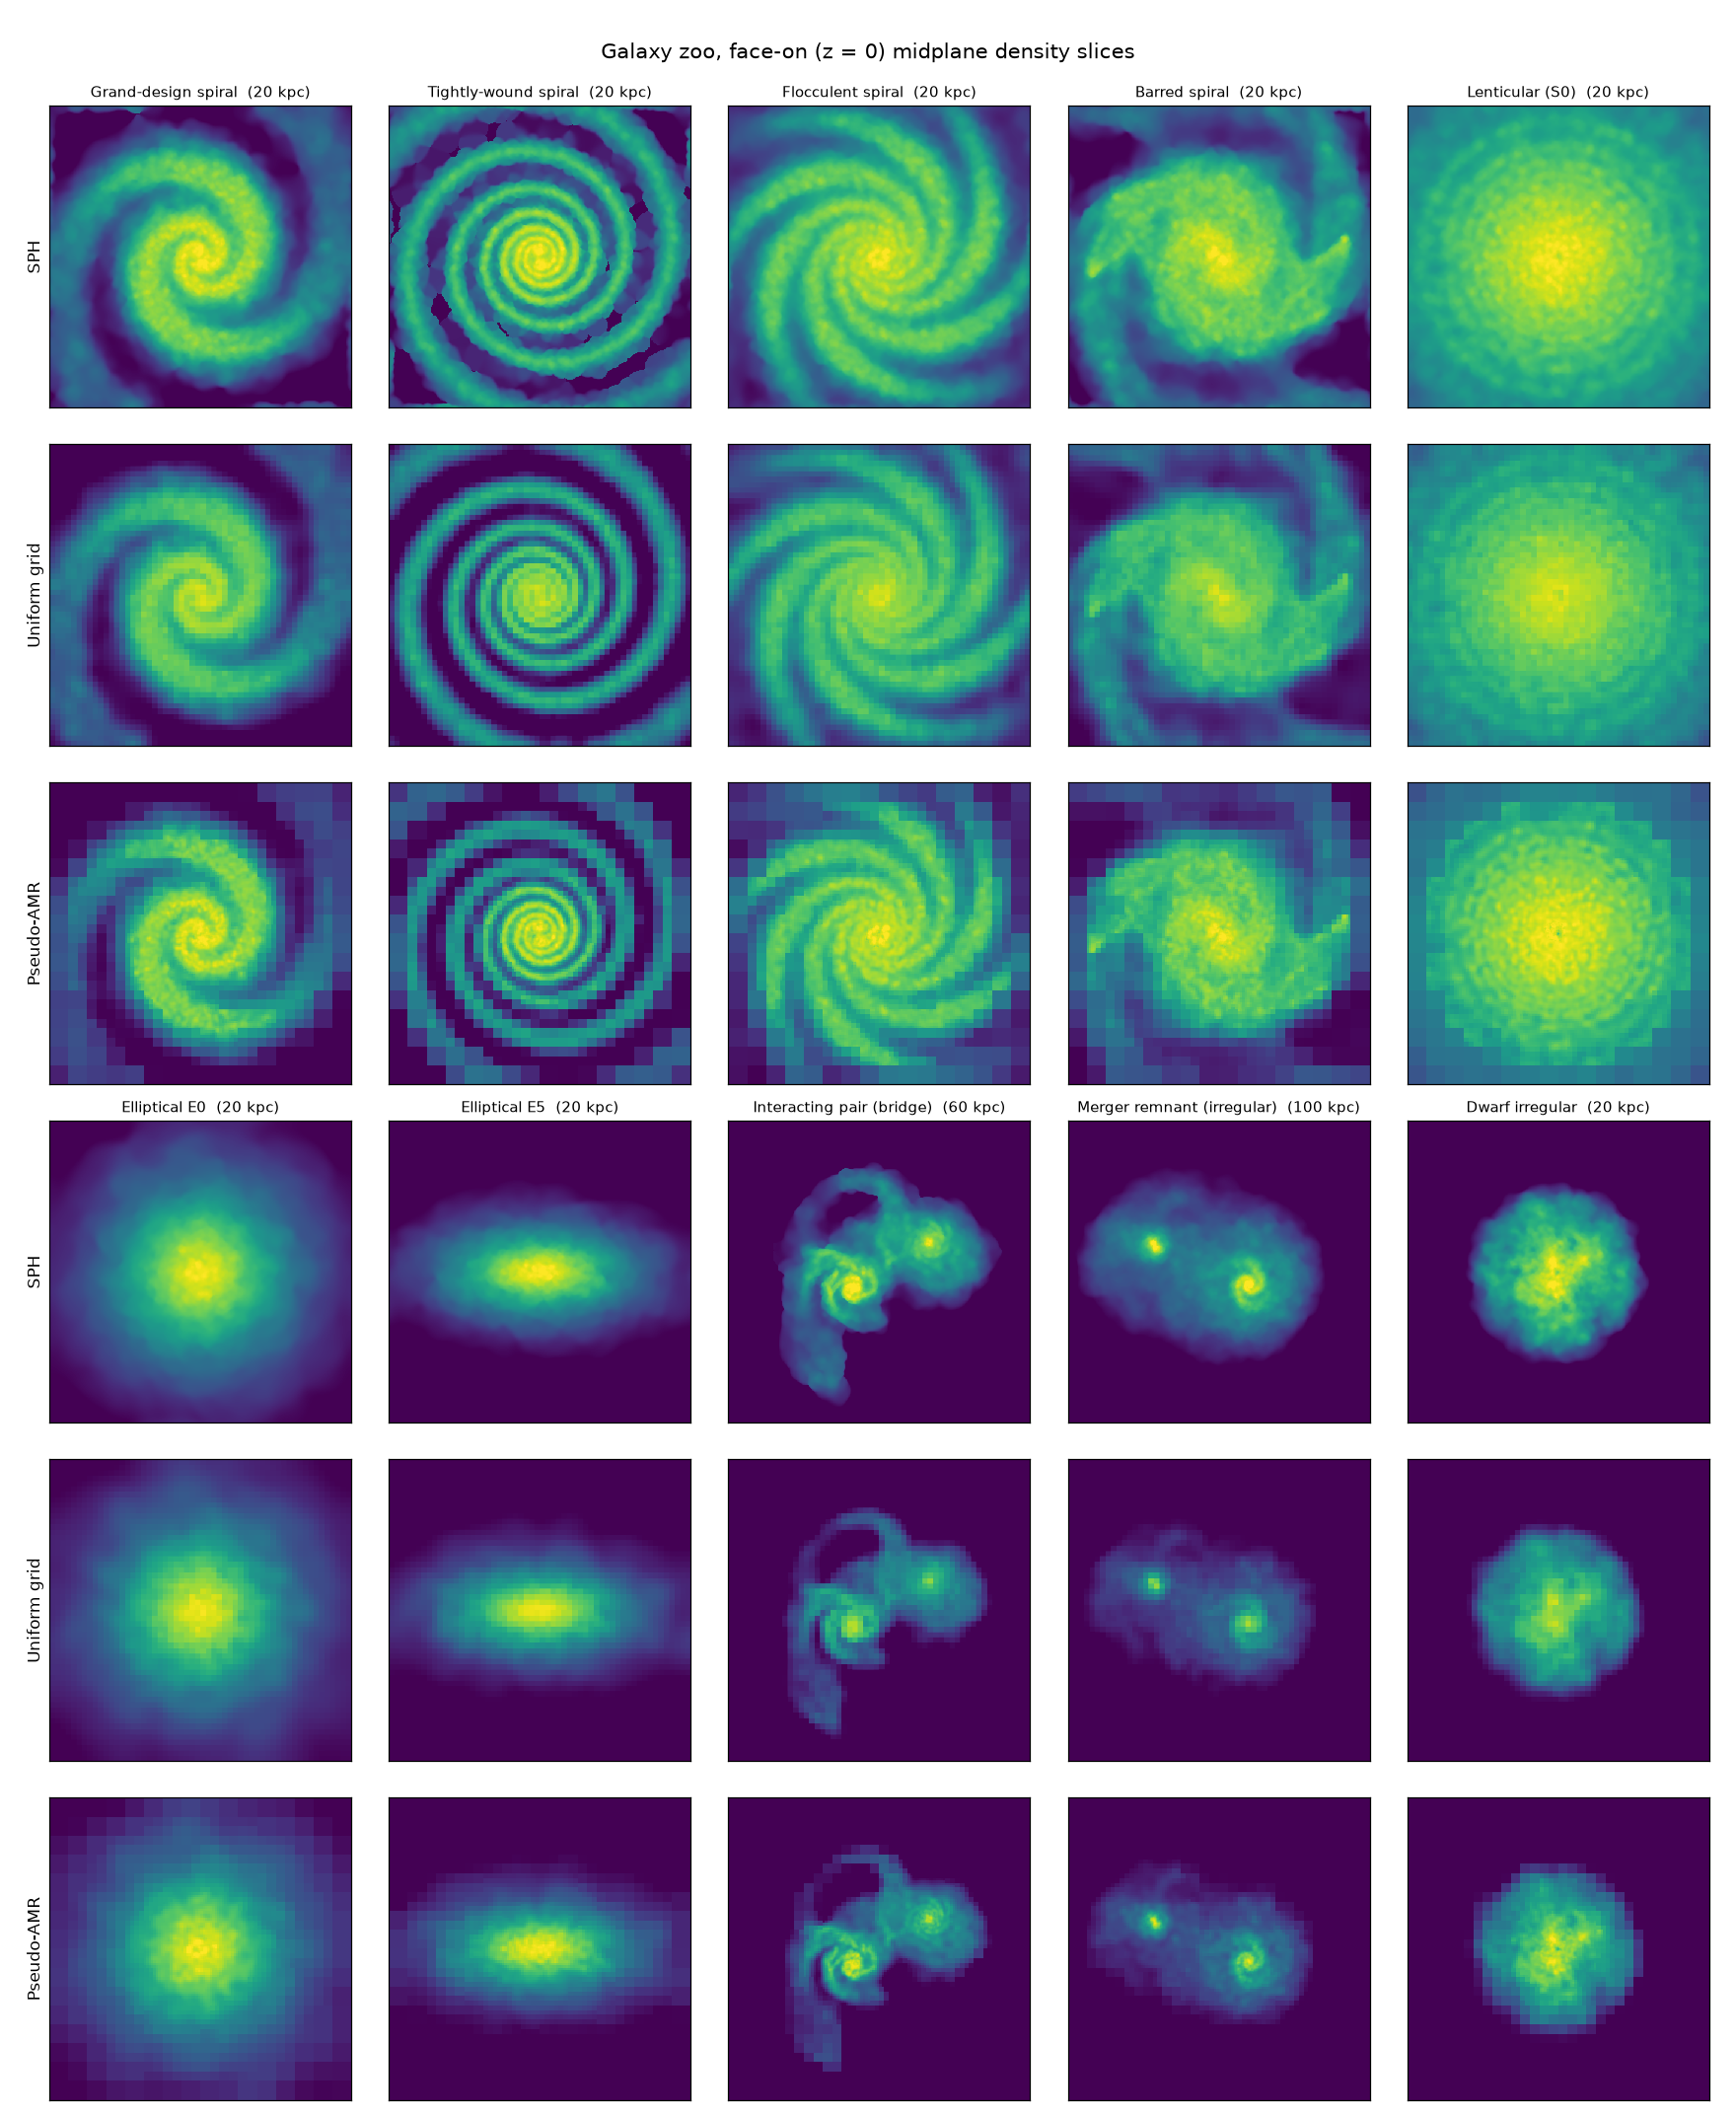

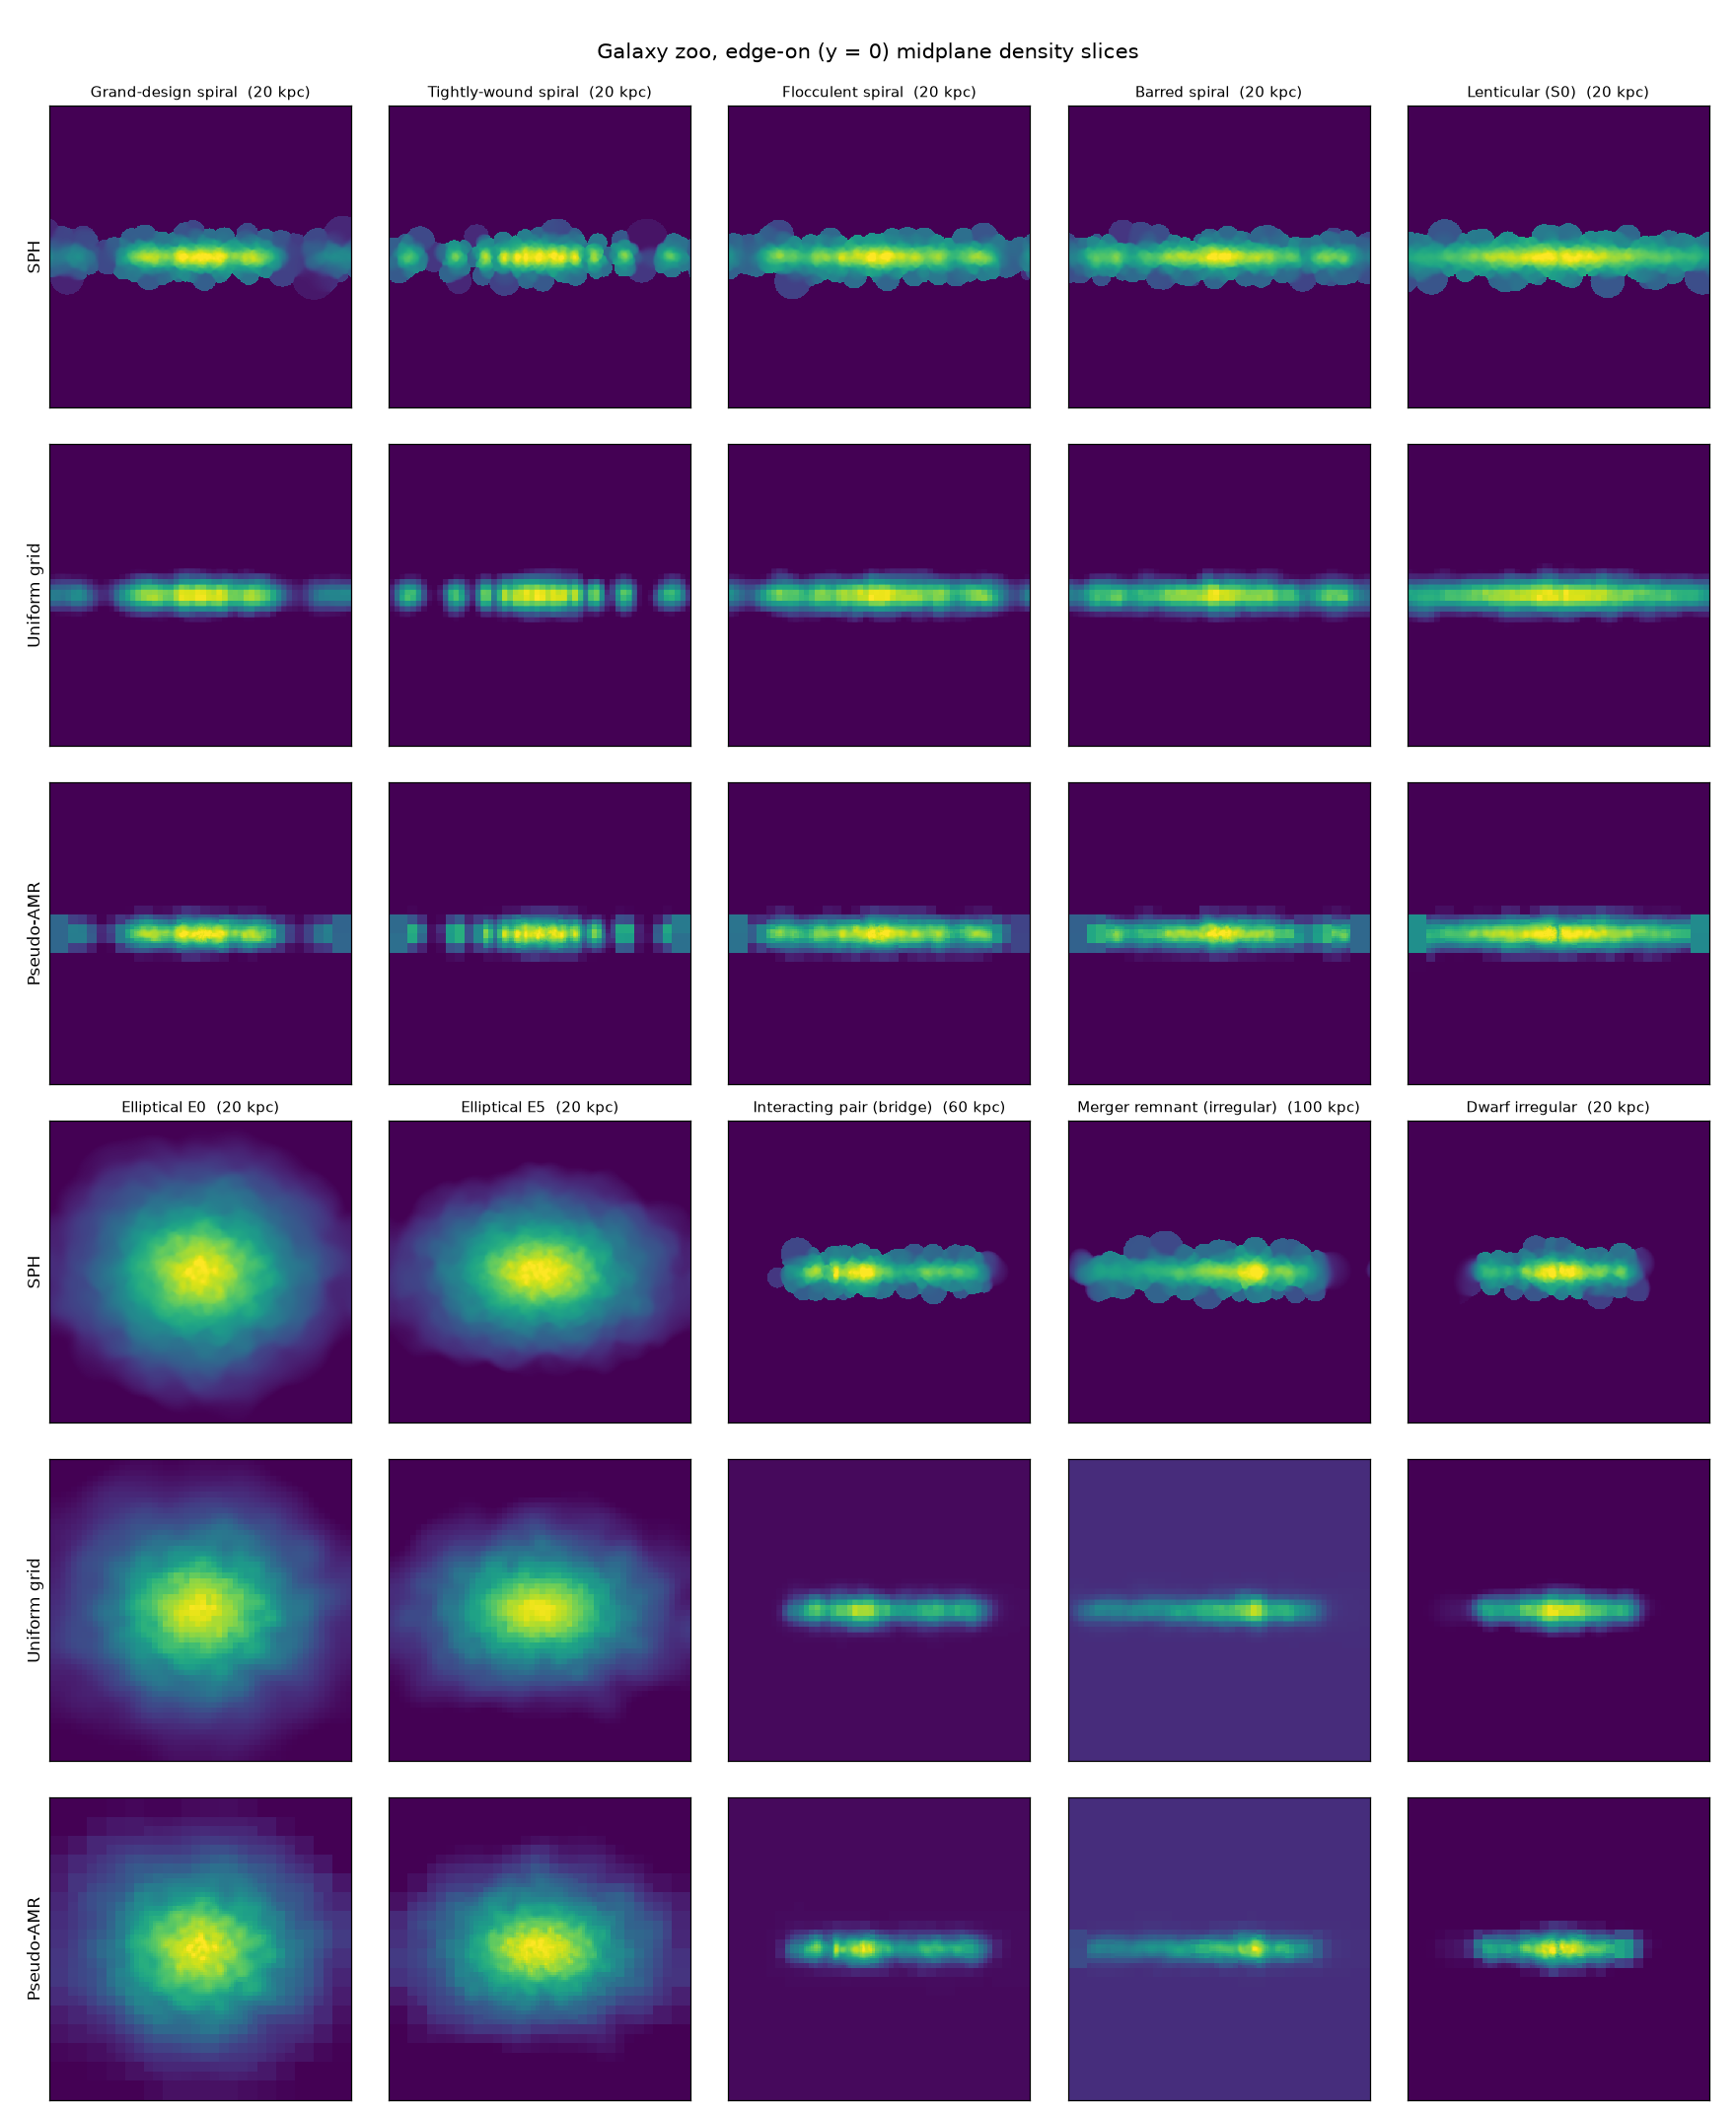

In [4]:
# Both montages (rows = SPH / uniform / AMR, one color scale per galaxy per
# view) are written straight from the cached slices in `frames` -- no yt or
# simulation calls happen here, so re-running this cell after tweaking
# dyn_range, e.g., is instant.
g.make_montages(frames, outdir=str(OUTDIR), dyn_range=3.0)

from IPython.display import Image, display
display(Image(filename=str(OUTDIR / "zoo_montage_faceon.png")))
display(Image(filename=str(OUTDIR / "zoo_montage_edgeon.png")))